In [ ]:
import pandas as pd
from typing import List, Union

def extract_numeric_value(value: str) -> float:
    """Extract numeric value from string, handling commas and unit suffixes."""
    return float(''.join(filter(str.isdigit, str(value))))

def clean_numeric_columns(df: pd.DataFrame, columns: List[str]) -> pd.DataFrame:
    """
    Clean numeric columns by removing commas and unit suffixes.
    
    Args:
        df: DataFrame containing numeric columns to clean
        columns: List of column names to process
    
    Returns:
        DataFrame with cleaned numeric columns
    """
    result_df = df.copy()
    for col in columns:
        result_df[col] = result_df[col].apply(extract_numeric_value)
    return result_df

# Usage
df = pd.read_csv(r"E:\Codding work\DataForDataScienceAndAI\Cars_data.csv")
numeric_cols = ["pu", "km_driven", "mileage_new", "max_engine_capacity_new"]
df = clean_numeric_columns(df, numeric_cols)

# Add car age column
df["car_age"] = 2025 - df["model_year_new"]

<>:4: SyntaxWarning: invalid escape sequence '\D'
<>:4: SyntaxWarning: invalid escape sequence '\D'
C:\Users\narut\AppData\Local\Temp\ipykernel_16404\4042324804.py:4: SyntaxWarning: invalid escape sequence '\D'
  df = pd.read_csv("E:\\Codding work\\\DataForDataScienceAndAI\\Cars_data.csv")


         pu  km_driven  mileage_new  max_engine_capacity_new
0  950000.0   150000.0        12.99                   2494.0
1  500000.0    53755.0        15.10                   2179.0
2  738000.0    53838.0        18.53                   1199.0
3  850000.0    28112.0        15.80                   1591.0
4  899999.0    63125.0        24.52                   1248.0


In [ ]:
# Filter and optimize memory usage in one step
df = df[df["car_age"] <= 30].reset_index(drop=True)

In [ ]:
# Define mapping with type hints
owner_type_order: dict[str, int] = {
    "Individual": 1,
    "Dealer": 2
}

# Create encoded column with error handling
df["utype_encoded"] = df["utype"].map(owner_type_order).fillna(0).astype(int)

# Display results
print("\nUnique values in utype column:")
print(df['utype'].unique())
print("\nFirst few rows with encoded values:")
print(df[["utype_encoded", "utype"]].head())

['Individual' 'Dealer']
   utype_encoded       utype
0              1  Individual
1              2      Dealer
2              2      Dealer
3              2      Dealer
4              2      Dealer


In [ ]:
from typing import Dict, Any

# Define ordinal mapping with type hints
owner_type_order: Dict[str, int] = {
    "fifth": 1,
    "fourth": 2,
    "third": 3,
    "second": 4,
    "first": 5,
    "unregistered car": 6
}

# Create encoded column with vectorized operations
df["owner_type_encoded"] = (
    df["owner_type_new"]
    .map(owner_type_order)
    .fillna(0)  # Handle unexpected values
    .astype(int)  # Ensure integer type
)

# Display results
print("\nUnique values in owner_type_new column:")
print(df['owner_type_new'].unique())
print("\nFirst few rows with encoded values:")
print(df[["owner_type_encoded", "owner_type_new"]].head())

['second' 'first' 'third' 'fourth' 'fifth' 'unregistered car']
  owner_type_new  owner_type_encoded
0         second                   4
1          first                   5
2          first                   5
3          first                   5
4          first                   5


In [ ]:
# Define extraction pattern with type hints
import pandas as pd
from typing import Union

def extract_numeric(value: Union[str, float, None]) -> float:
    """Extract numeric value from string, handling various formats."""
    try:
        # Handle None values
        if pd.isna(value):
            return 0.0
            
        # Extract numeric part using regex
        numeric_match = pd.to_numeric(
            str(value).str.extract(r"(\d+\.\d+|\d+)")[0],
            errors='coerce'
        )
        
        # Handle extraction failures
        return numeric_match.fillna(0.0).float()
    except Exception:
        return 0.0

# Apply extraction to both columns
df["max_power"] = df["Max Power"].apply(extract_numeric)
df["max_torque"] = df["Max Torque"].apply(extract_numeric)

In [ ]:
# Define columns to check
price_cols = ["pu", "mileage_new"]

# Display missing value counts before cleaning
print("Missing values before cleaning:")
print(df[price_cols].isnull().sum())

# Drop rows with missing price
df.dropna(subset=["pu"], inplace=True)

# Fill missing mileage with median
df["mileage_new"] = df["mileage_new"].fillna(df["mileage_new"].median())

# Display missing value counts after cleaning
print("\nMissing values after cleaning:")
print(df[price_cols].isnull().sum())

In [ ]:
# Define performance columns and validation function
perf_cols = ["Top Speed", "Acceleration"]

def clean_performance(value: str) -> float:
    """Extract numeric value from performance metric string."""
    try:
        # Handle None values
        if pd.isna(value):
            return 0.0
            
        # Extract numeric part using regex
        numeric_match = pd.to_numeric(
            str(value).str.extract(r"([0-9.]+)")[0],
            errors='coerce'
        )
        
        # Handle extraction failures
        return numeric_match.fillna(0.0).float()
    except Exception:
        return 0.0

# Apply cleaning and validation
for col in perf_cols:
    print(f"\nBefore cleaning {col}:")
    print(df[col].head())
    
    # Clean and convert to float
    df[col] = df[col].apply(clean_performance)
    
    # Fill missing values with median
    df[col] = df[col].fillna(df[col].median())
    
    print(f"After cleaning {col}:")
    print(df[col].head())

In [ ]:
# Define columns to check
required_cols = ["mileage_new", "max_power", "max_torque", "No of Cylinder"]

# Display missing value counts before cleaning
print("Missing values before cleaning:")
print(df[required_cols].isnull().sum())

# Drop rows with missing values in any required column
df = df.dropna(subset=required_cols)

# Display missing value counts after cleaning
print("\nMissing values after cleaning:")
print(df[required_cols].isnull().sum())

# Display impact on dataset size
print(f"\nDataset size before cleaning: {len(df) + len(df[required_cols].isnull().any(axis=1))}")
print(f"Dataset size after cleaning: {len(df)}")

In [ ]:
# Define performance columns
perf_cols = ["max_power", "max_torque"]

# Display missing values before imputation
print("Missing values before imputation:")
print(df[perf_cols].isnull().sum())

# Impute missing values with median
df[perf_cols] = df[perf_cols].fillna(df[perf_cols].median())

# Display validation statistics
print("\nValidation statistics:")
print(df[perf_cols].describe())

In [ ]:
# Display statistics before filtering
print("Before filtering:")
print(f"Total rows: {len(df)}")
print(f"Zero engine capacity count: {(df['max_engine_capacity_new'] == 0).sum()}")
print(f"Mean engine capacity: {df['max_engine_capacity_new'].mean():.2f}")

# Filter out zero values
df = df[df['max_engine_capacity_new'] != 0]

# Display validation after filtering
print("\nAfter filtering:")
print(f"Total rows: {len(df)}")
print(f"Mean engine capacity: {df['max_engine_capacity_new'].mean():.2f}")
print(f"Min engine capacity: {df['max_engine_capacity_new'].min():.2f}")

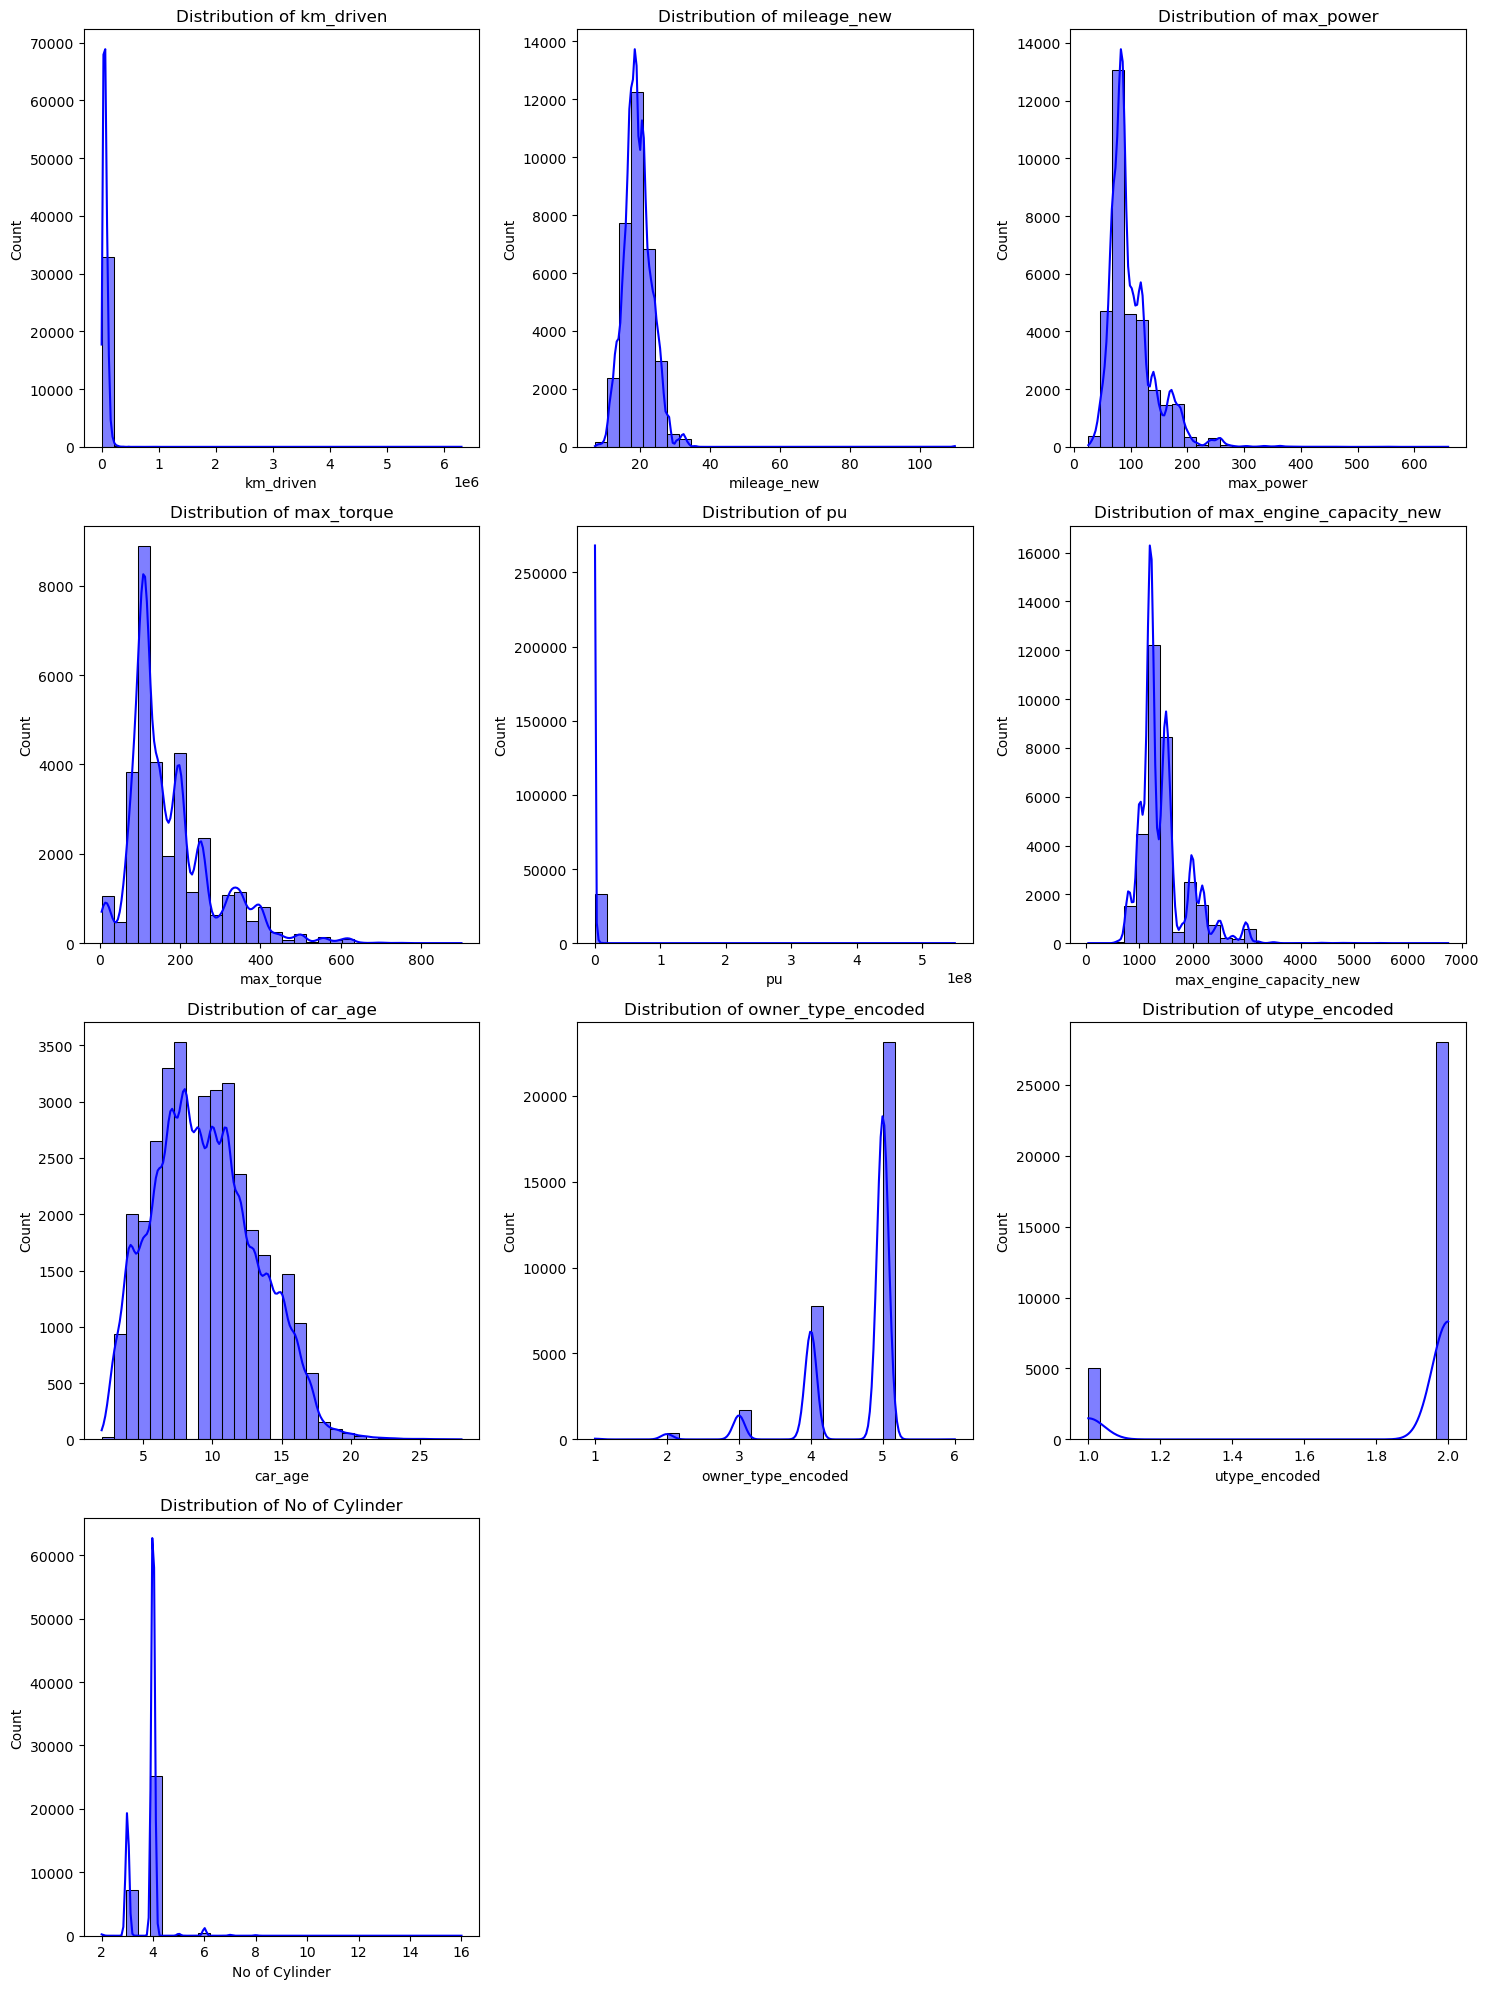

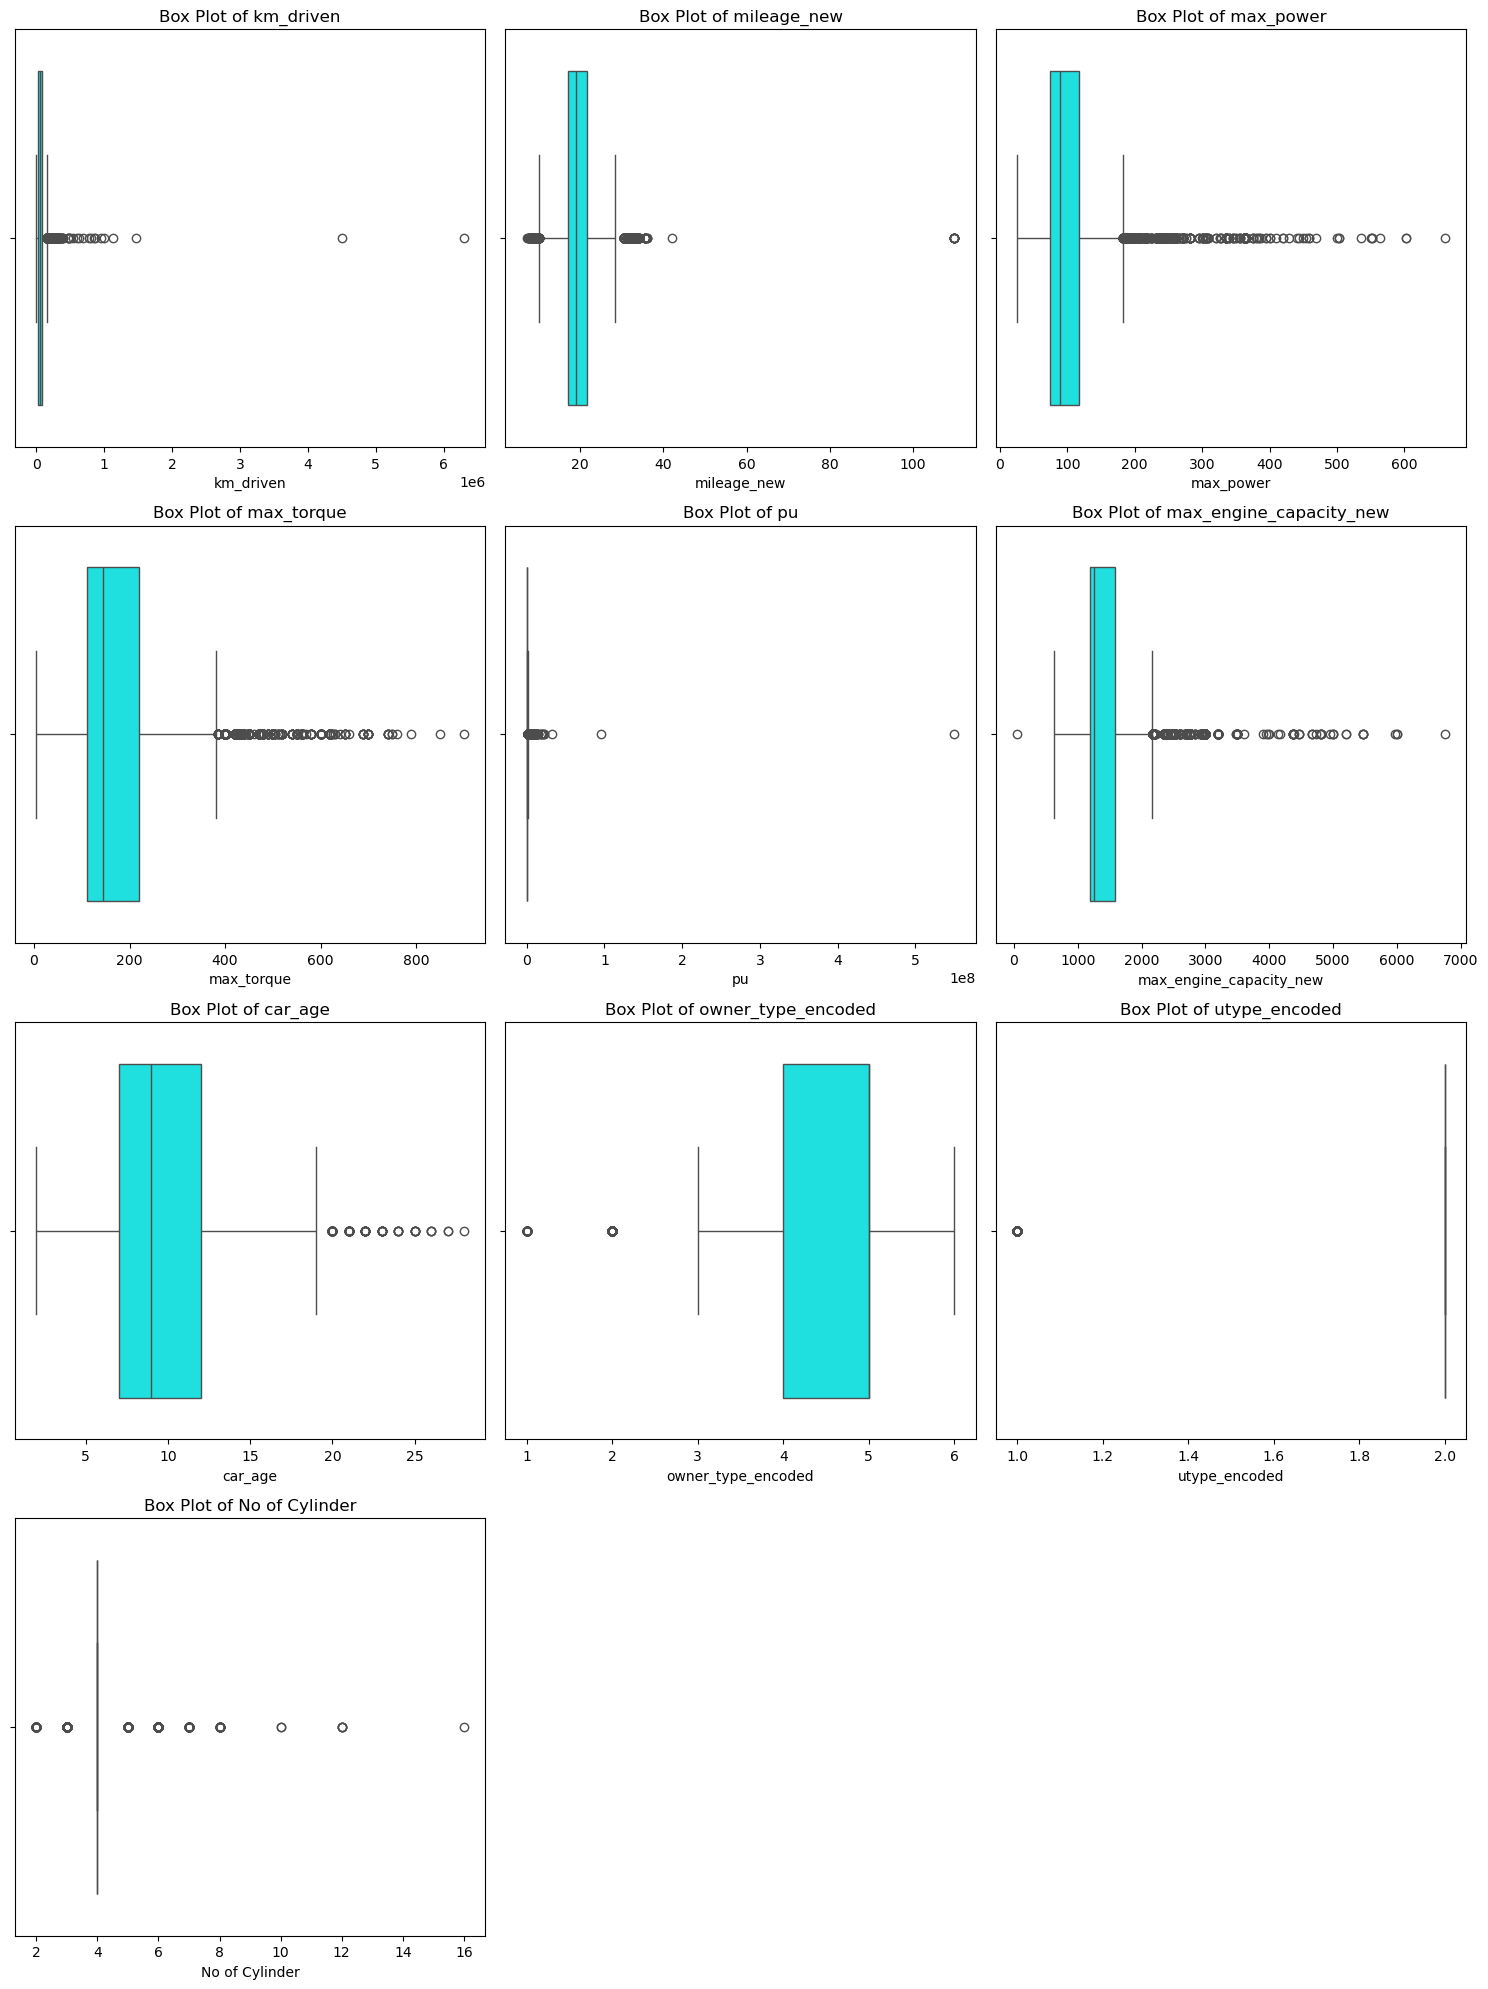

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Define numerical columns
numerical_columns = [
    "km_driven", "mileage_new",
    "max_power", "max_torque", "pu",
    "max_engine_capacity_new", "car_age", 
    "owner_type_encoded", "utype_encoded", "No of Cylinder"
]

# Calculate grid dimensions
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)

# Create figure with optimized size
plt.figure(figsize=(15, 5 * n_rows))

# Plot histograms with vectorized operations
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

# Create box plots with memory-efficient approach
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np

# Define columns for outlier detection
log_cols = ["owner_type_encoded", 'max_power', 'max_torque', 'max_engine_capacity_new', 
             "km_driven", "car_age", "mileage_new", "pu"]

# Display statistics before outlier removal
print("Before outlier removal:")
print(df[log_cols].describe())

# Create mask for valid values using vectorized operations
valid_mask = np.ones(len(df), dtype=bool)
for col in log_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    valid_mask &= (df[col] >= (Q1 - 1.5 * IQR)) & (df[col] <= (Q3 + 1.5 * IQR))

# Apply filter and show impact
print(f"\nRemoving {sum(~valid_mask)} rows with outliers")
df = df[valid_mask]

# Display validation after outlier removal
print("\nAfter outlier removal:")
print(df[log_cols].describe())

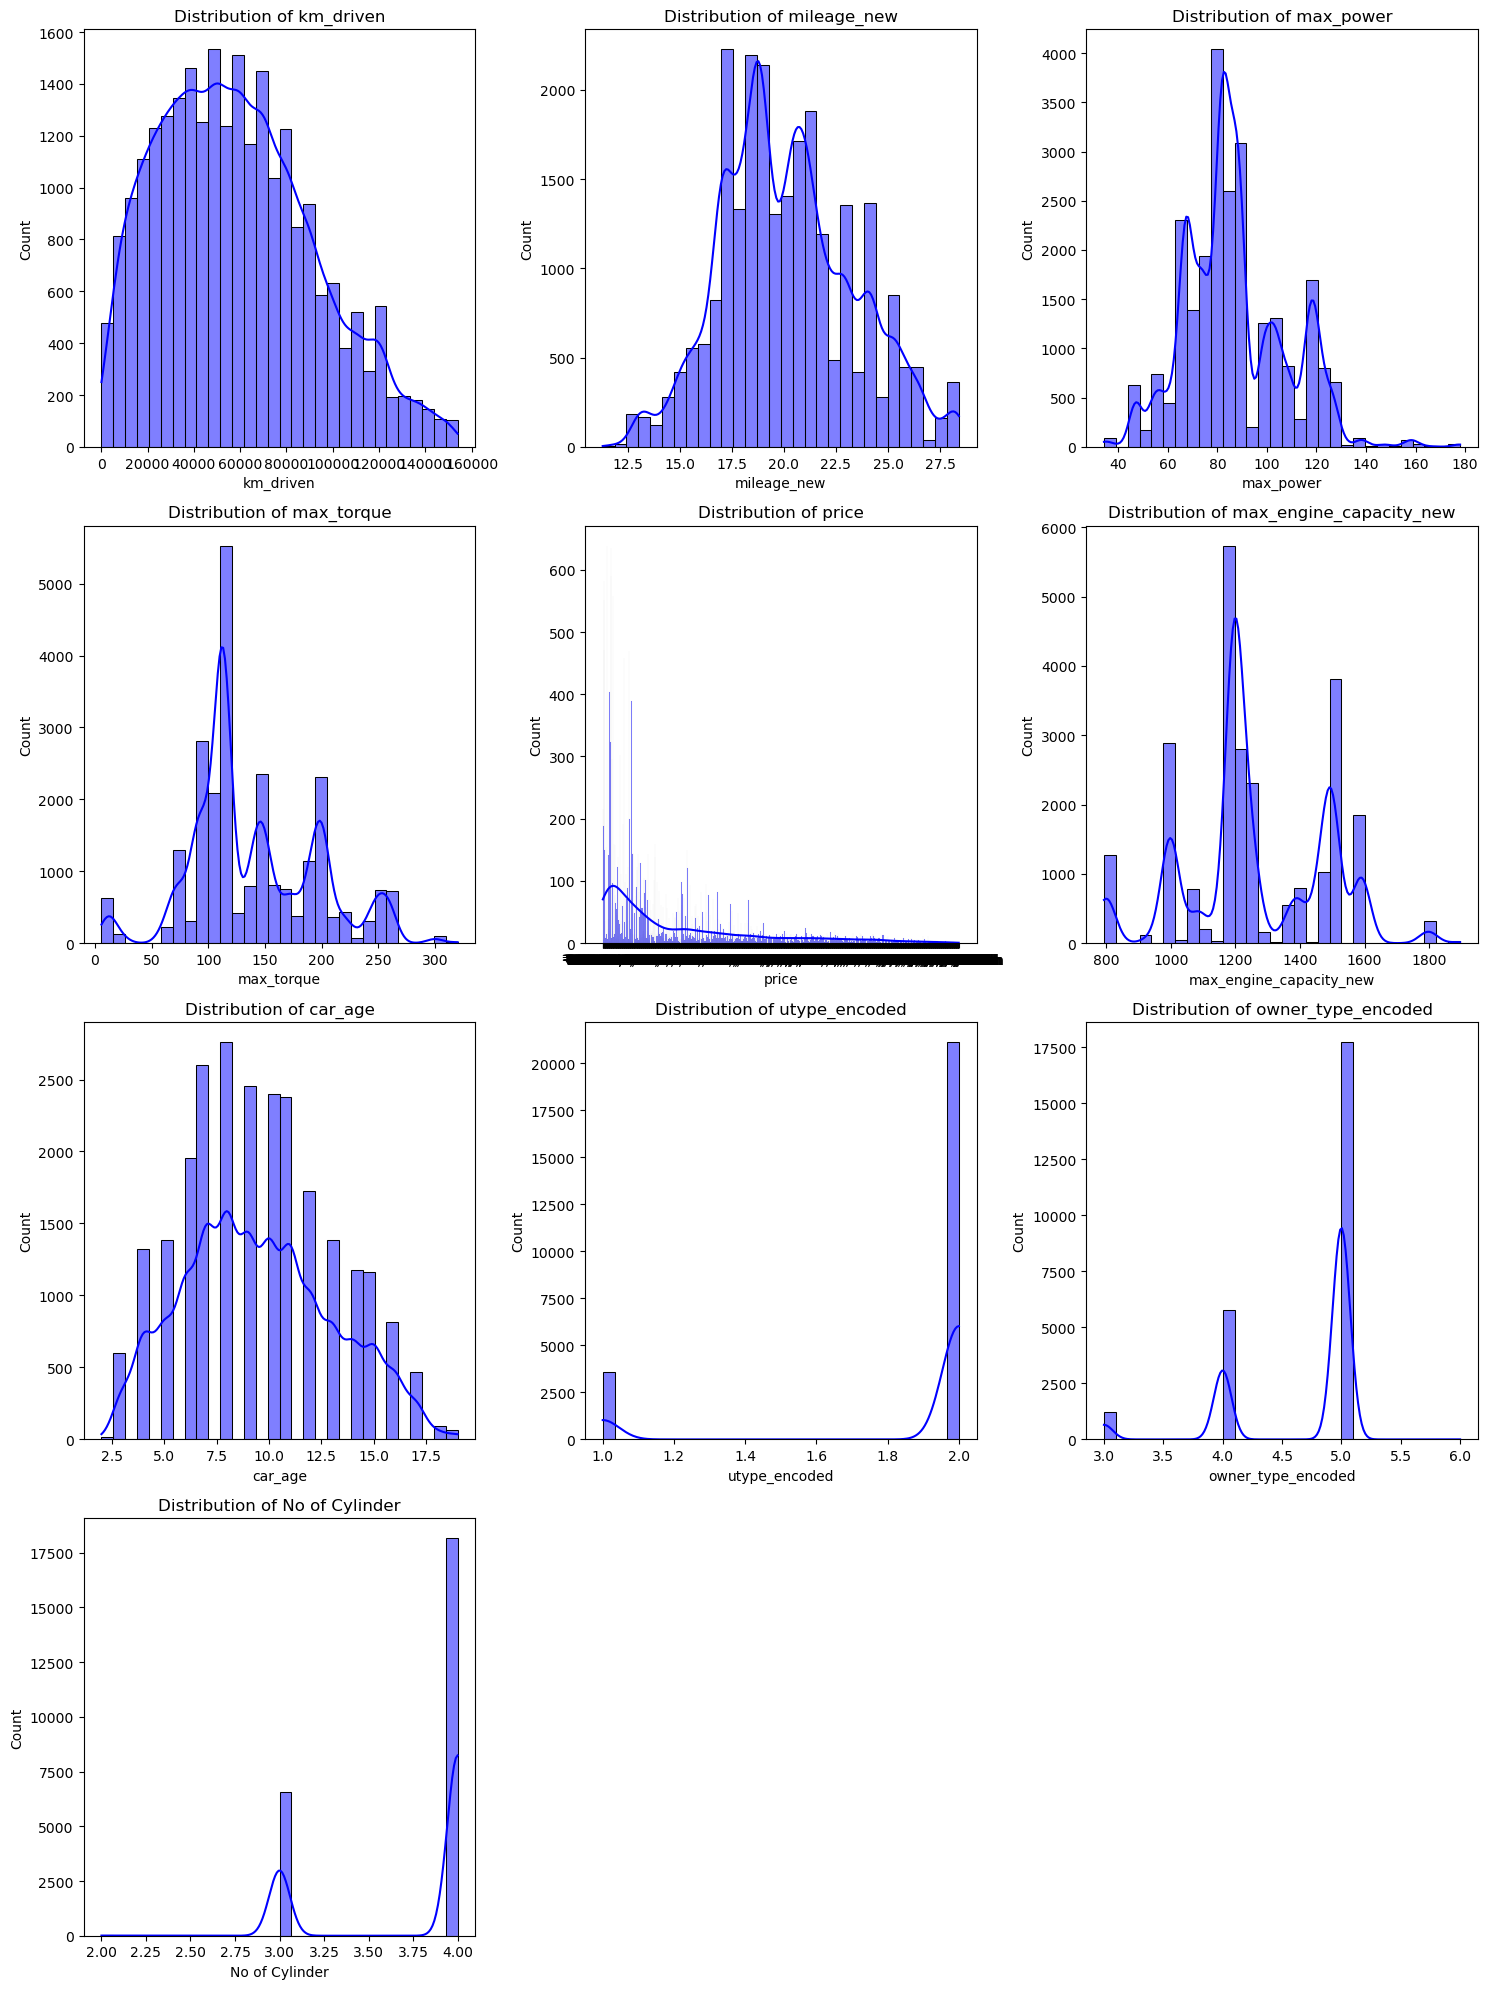

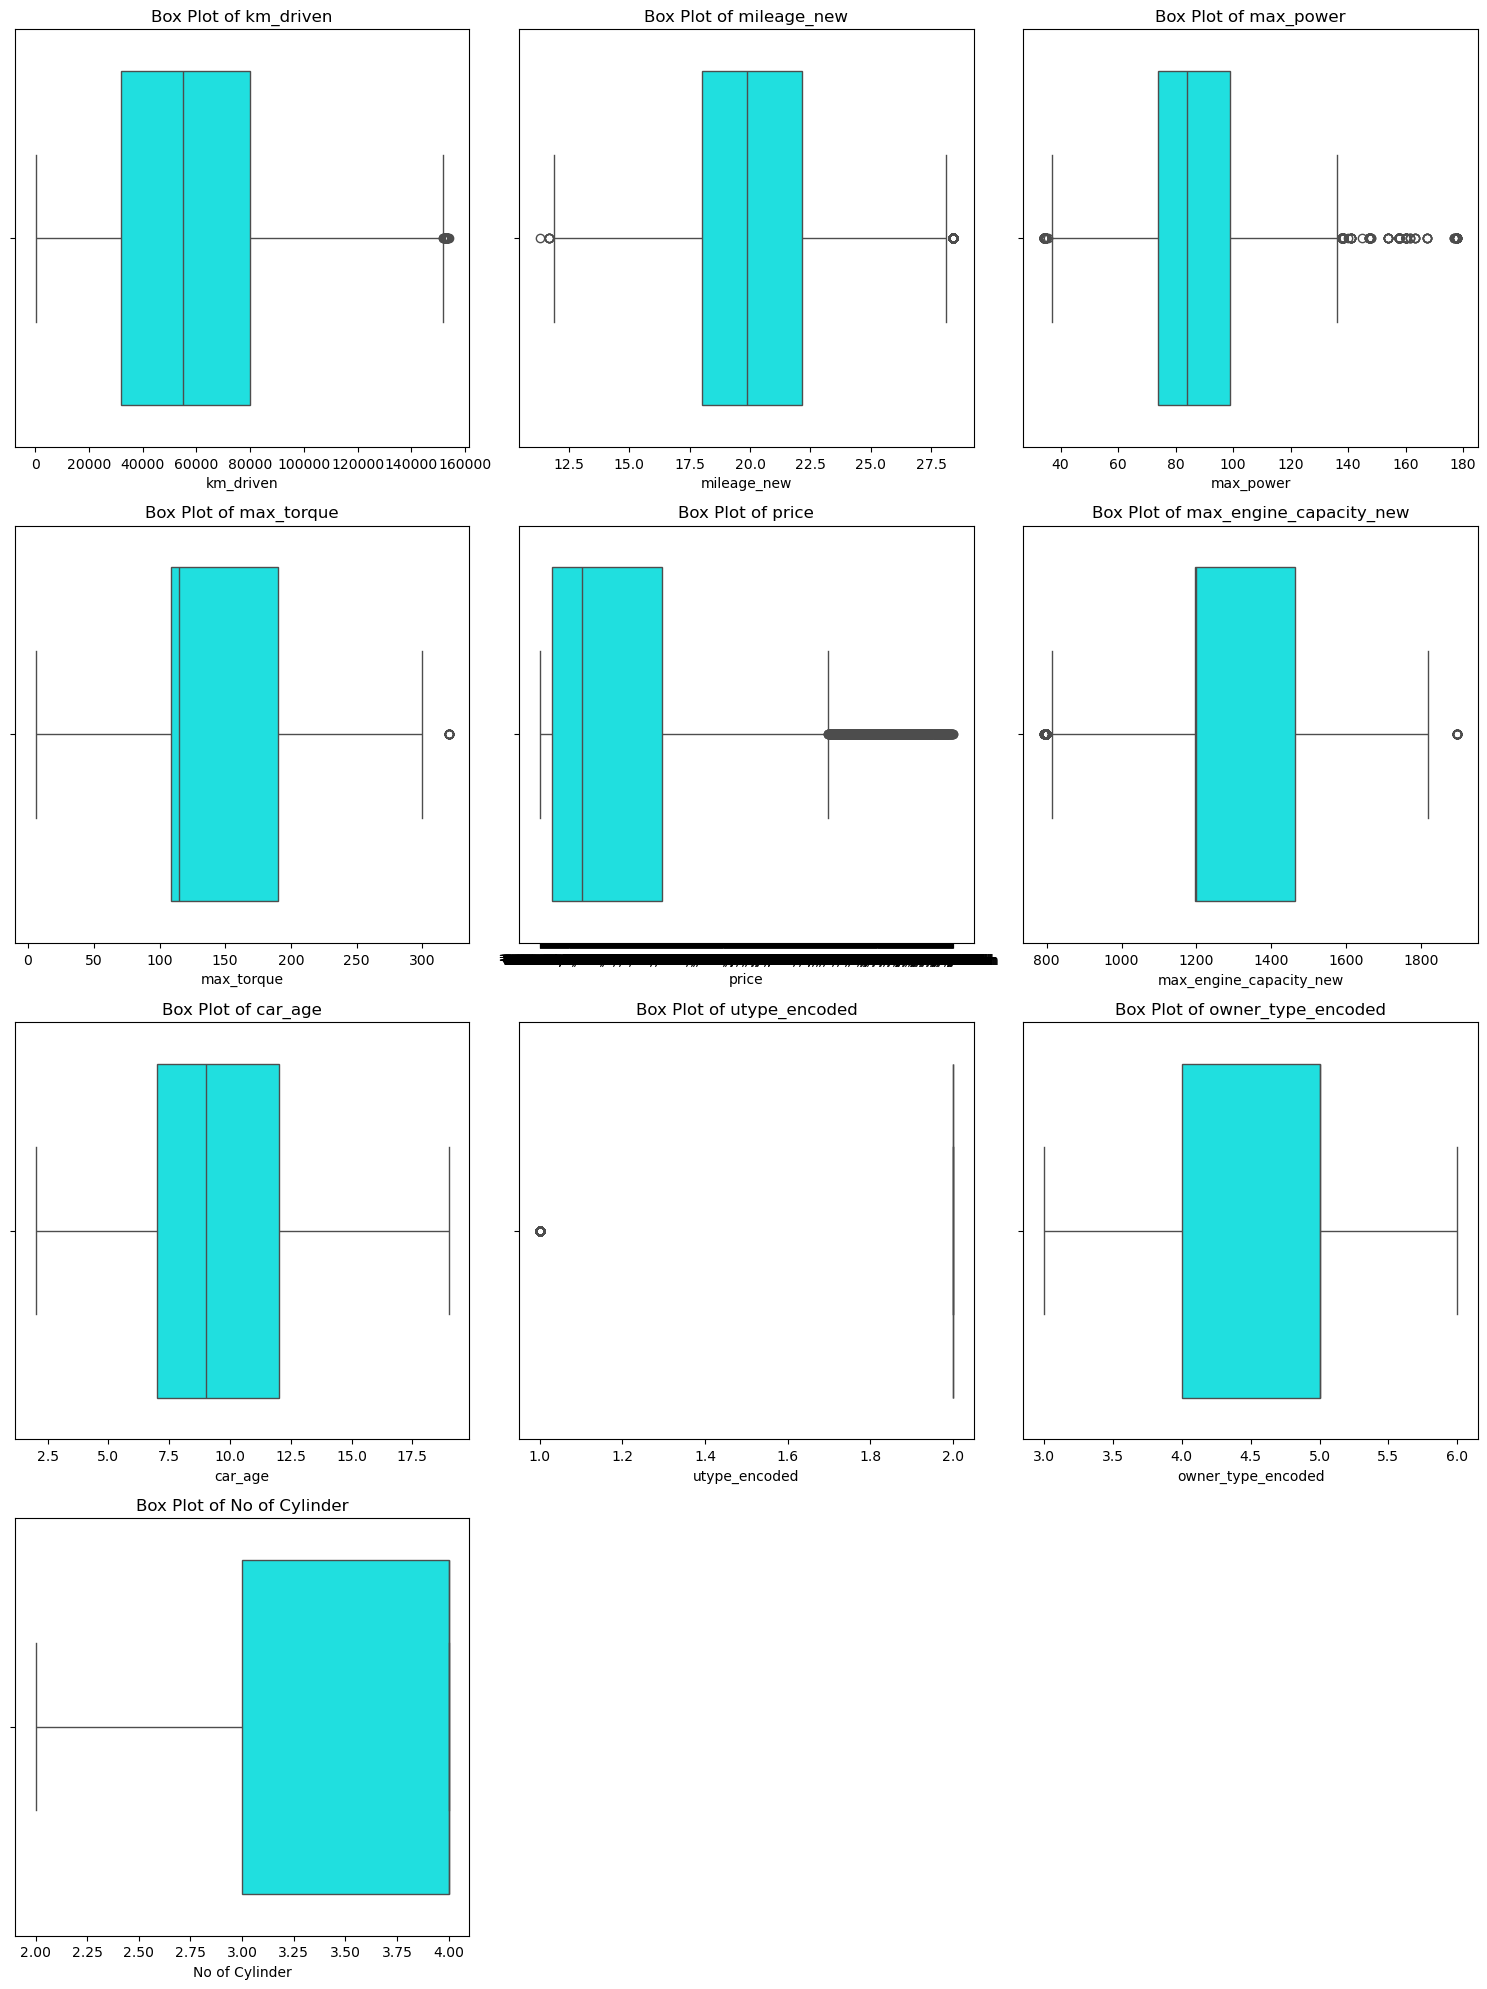

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

# Define numerical columns
numerical_columns = [
    "km_driven", "mileage_new",
    "max_power", "max_torque", "pu",
    "max_engine_capacity_new", "car_age", 
    "owner_type_encoded", "utype_encoded", "No of Cylinder"
]

# Calculate grid dimensions
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)

# Create figure with optimized size
plt.figure(figsize=(15, 5 * n_rows))

# Plot histograms with vectorized operations
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')

plt.tight_layout()
plt.show()

# Create box plots with memory-efficient approach
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')

plt.tight_layout()
plt.show()

In [ ]:
import numpy as np
from scipy.stats import boxcox

# Define transformation mappings
transformations = {
    'log': {
        'columns': ['max_power', 'max_torque', 'max_engine_capacity_new', 
                   'km_driven', 'car_age', 'mileage_new', 'No of Cylinder'],
        'function': np.log
    },
    'sqrt': {
        'columns': ['max_torque', 'km_driven'],
        'function': np.sqrt
    },
    'boxcox': {
        'columns': ['max_torque', 'km_driven'],
        'function': lambda x: boxcox(x)[0]
    }
}

# Display statistics before transformation
print("Before transformations:")
for col in transformations['log']['columns']:
    print(f"\n{col} statistics:")
    print(df[col].describe())

# Apply transformations
for transform_type, config in transformations.items():
    for col in config['columns']:
        # Create new column with transformed values
        new_col = f"{col}_{transform_type}"
        df[new_col] = config['function'](df[col])

# Display validation after transformations
print("\nAfter transformations:")
for col in transformations['log']['columns']:
    print(f"\n{col} and {col}_log statistics:")
    print(f"Original skewness: {df[col].skew():.2f}")
    print(f"Transformed skewness: {df[f'{col}_log'].skew():.2f}")

In [ ]:
import numpy as np

# Define features and validation function
features = [
    "km_driven_sqrt", "mileage_new",
    "log_max_power", "log_max_torque",
    "log_max_engine_capacity_new", "car_age",
    "owner_type_encoded", "utype_encoded", "No of Cylinder", 
    "Top Speed", "Acceleration"
]

def validate_features(df, features):
    """Validate feature data quality and return clean DataFrame."""
    # Display initial missing values
    print("Missing values before cleaning:")
    print(df[features].isnull().sum())
    
    # Clean data in one operation
    df = df.dropna(subset=["pu"])
    df = df.dropna(subset=features)
    
    # Create feature matrix and target
    X = df[features]
    y = np.log(df["pu"])
    
    # Display validation statistics
    print("\nFeature statistics after cleaning:")
    print(X.describe())
    print("\nTarget statistics:")
    print(y.describe())
    
    return X, y

# Apply validation and create matrices
X, y = validate_features(df, features)

In [ ]:
# Display statistics before validation
print("Before validation:")
print(f"Total rows: {len(df)}")
print(f"Negative values: {sum(df['max_engine_capacity_new'] < 0)}")
print(f"Mean capacity: {df['max_engine_capacity_new'].mean():.2f}")
print(f"Min capacity: {df['max_engine_capacity_new'].min():.2f}")

# Create mask for valid values
valid_mask = df['max_engine_capacity_new'] >= 0

# Display validation results
print("\nValidation results:")
print(f"Rows with negative values: {sum(~valid_mask)}")
print("\nNegative values:")
print(df[~valid_mask][['max_engine_capacity_new']])

# Update DataFrame
df = df[valid_mask]

print("\nAfter validation:")
print(f"Total rows: {len(df)}")
print(f"Mean capacity: {df['max_engine_capacity_new'].mean():.2f}")
print(f"Min capacity: {df['max_engine_capacity_new'].min():.2f}")

Rows with negative 'max_engine_capacity_new':
Empty DataFrame
Columns: [max_engine_capacity_new]
Index: []
Total negative values: 0


In [ ]:
import numpy as np

# Define column and validation function
col = "pu"

def analyze_column_stats(df, column):
    """Analyze column statistics with validation."""
    # Display comprehensive statistics
    print(f"\nStatistics for {column}:")
    print(df[column].describe())
    
    # Calculate additional metrics
    print(f"\nAdditional metrics:")
    print(f"Standard deviation: {df[column].std():.2f}")
    print(f"Variance: {df[column].var():.2f}")
    print(f"Skewness: {df[column].skew():.2f}")
    
    # Display validation information
    print(f"\nValidation:")
    print(f"Missing values: {df[column].isnull().sum()}")
    print(f"Unique values: {df[column].nunique()}")
    print(f"Data type: {df[column].dtype}")

# Apply analysis
analyze_column_stats(df, col)

Min: 44444.0
Max: 1300000.0
Median: 454000.0
Mean: 502826.07641357026


In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

# Split data with validation
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=44,
    shuffle=True
)

# Scale data with validation
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Display validation statistics
print("Data split validation:")
print(f"Training set size: {len(X_train)}")
print(f"Validation set size: {len(X_val)}")
print(f"Total proportion: {(len(X_train) + len(X_val)) / len(X):.2%}")

print("\nScaling validation:")
print("Training set ranges:")
print(f"Min: {X_train_scaled.min(axis=0).min():.4f}")
print(f"Max: {X_train_scaled.max(axis=0).max():.4f}")
print("\nValidation set ranges:")
print(f"Min: {X_val_scaled.min(axis=0).min():.4f}")
print(f"Max: {X_val_scaled.max(axis=0).max():.4f}")

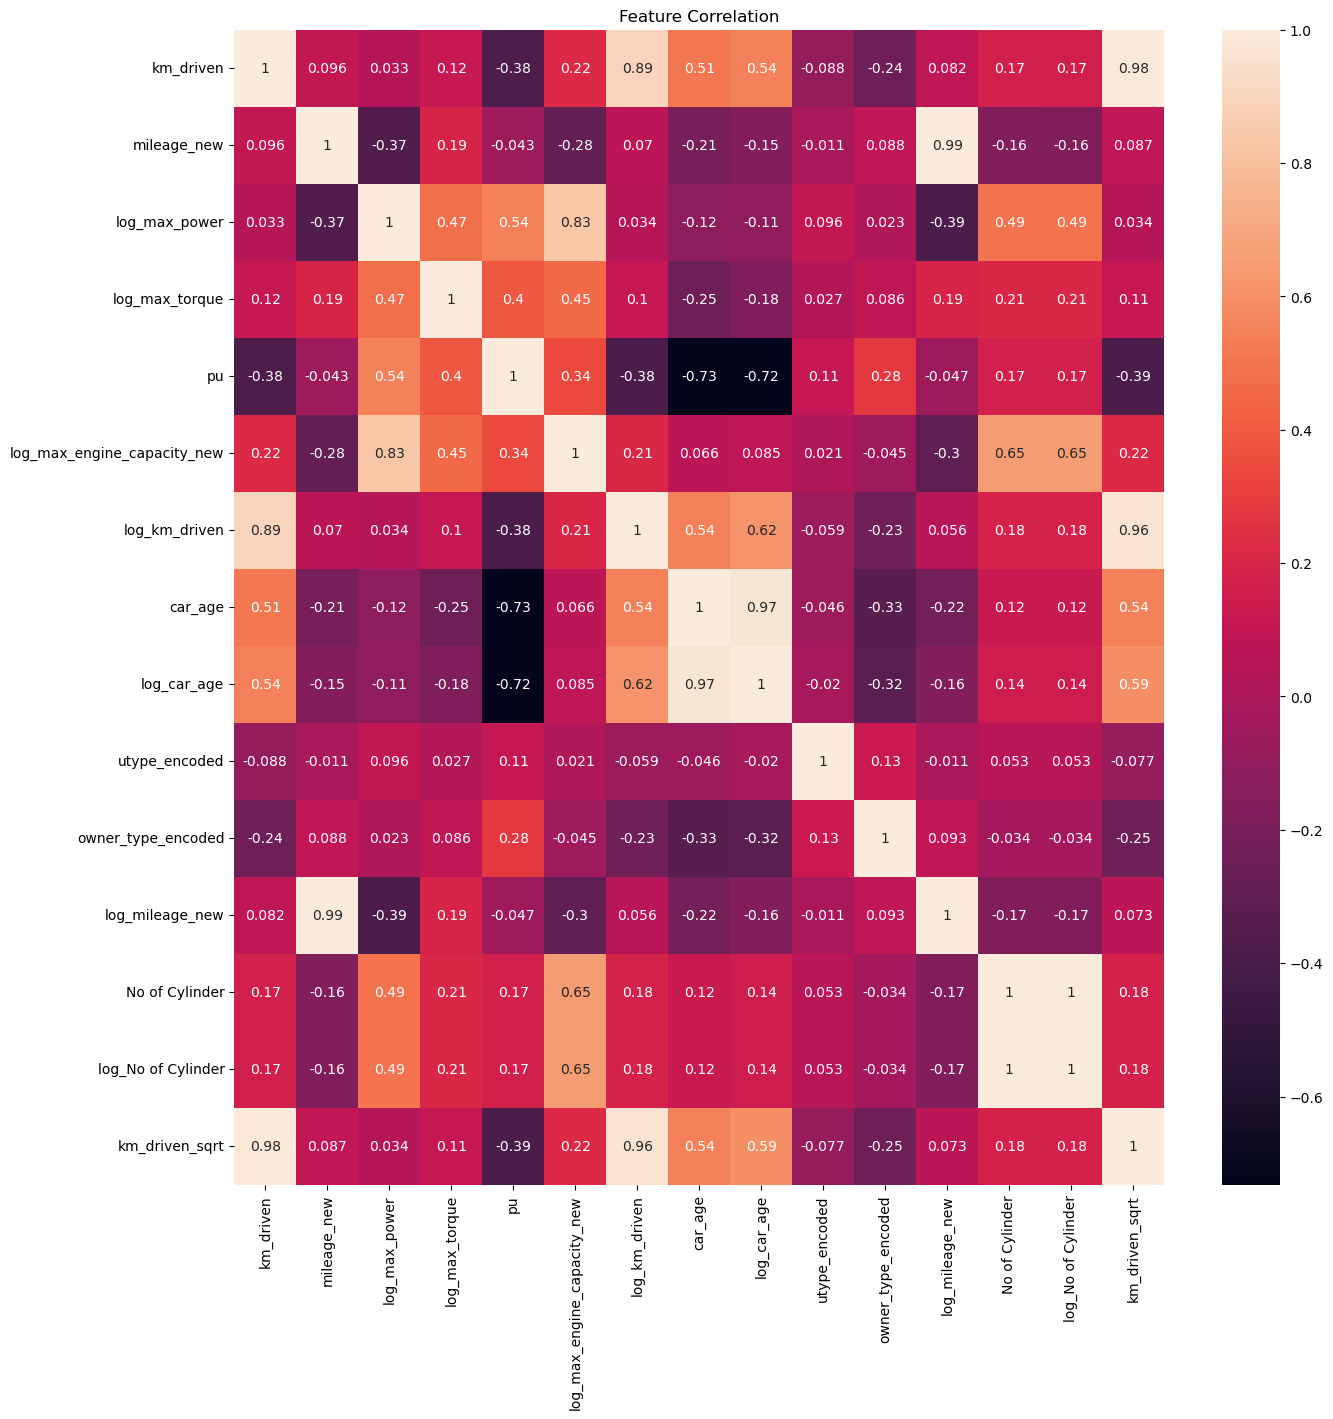

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Define numerical columns
numerical_cols = [
    "km_driven", "mileage_new", "log_max_power", "log_max_torque", "pu",
    "log_max_engine_capacity_new", "log_km_driven", "car_age", "log_car_age",
    "utype_encoded", "owner_type_encoded", "log_mileage_new", "No of Cylinder",
    "log_No of Cylinder", "km_driven_sqrt", "km_driven_boxcox"
]

# Create correlation matrix with validation
correlation_matrix = df[numerical_cols].corr()

# Display validation statistics
print("Correlation matrix validation:")
print(f"Matrix shape: {correlation_matrix.shape}")
print(f"Missing values: {correlation_matrix.isnull().sum().sum()}")
print(f"Self-correlations (should be 1.0):")
print(correlation_matrix.diagonal().describe())

# Create heatmap with optimized parameters
plt.figure(figsize=(15, 15))
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    square=True
)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

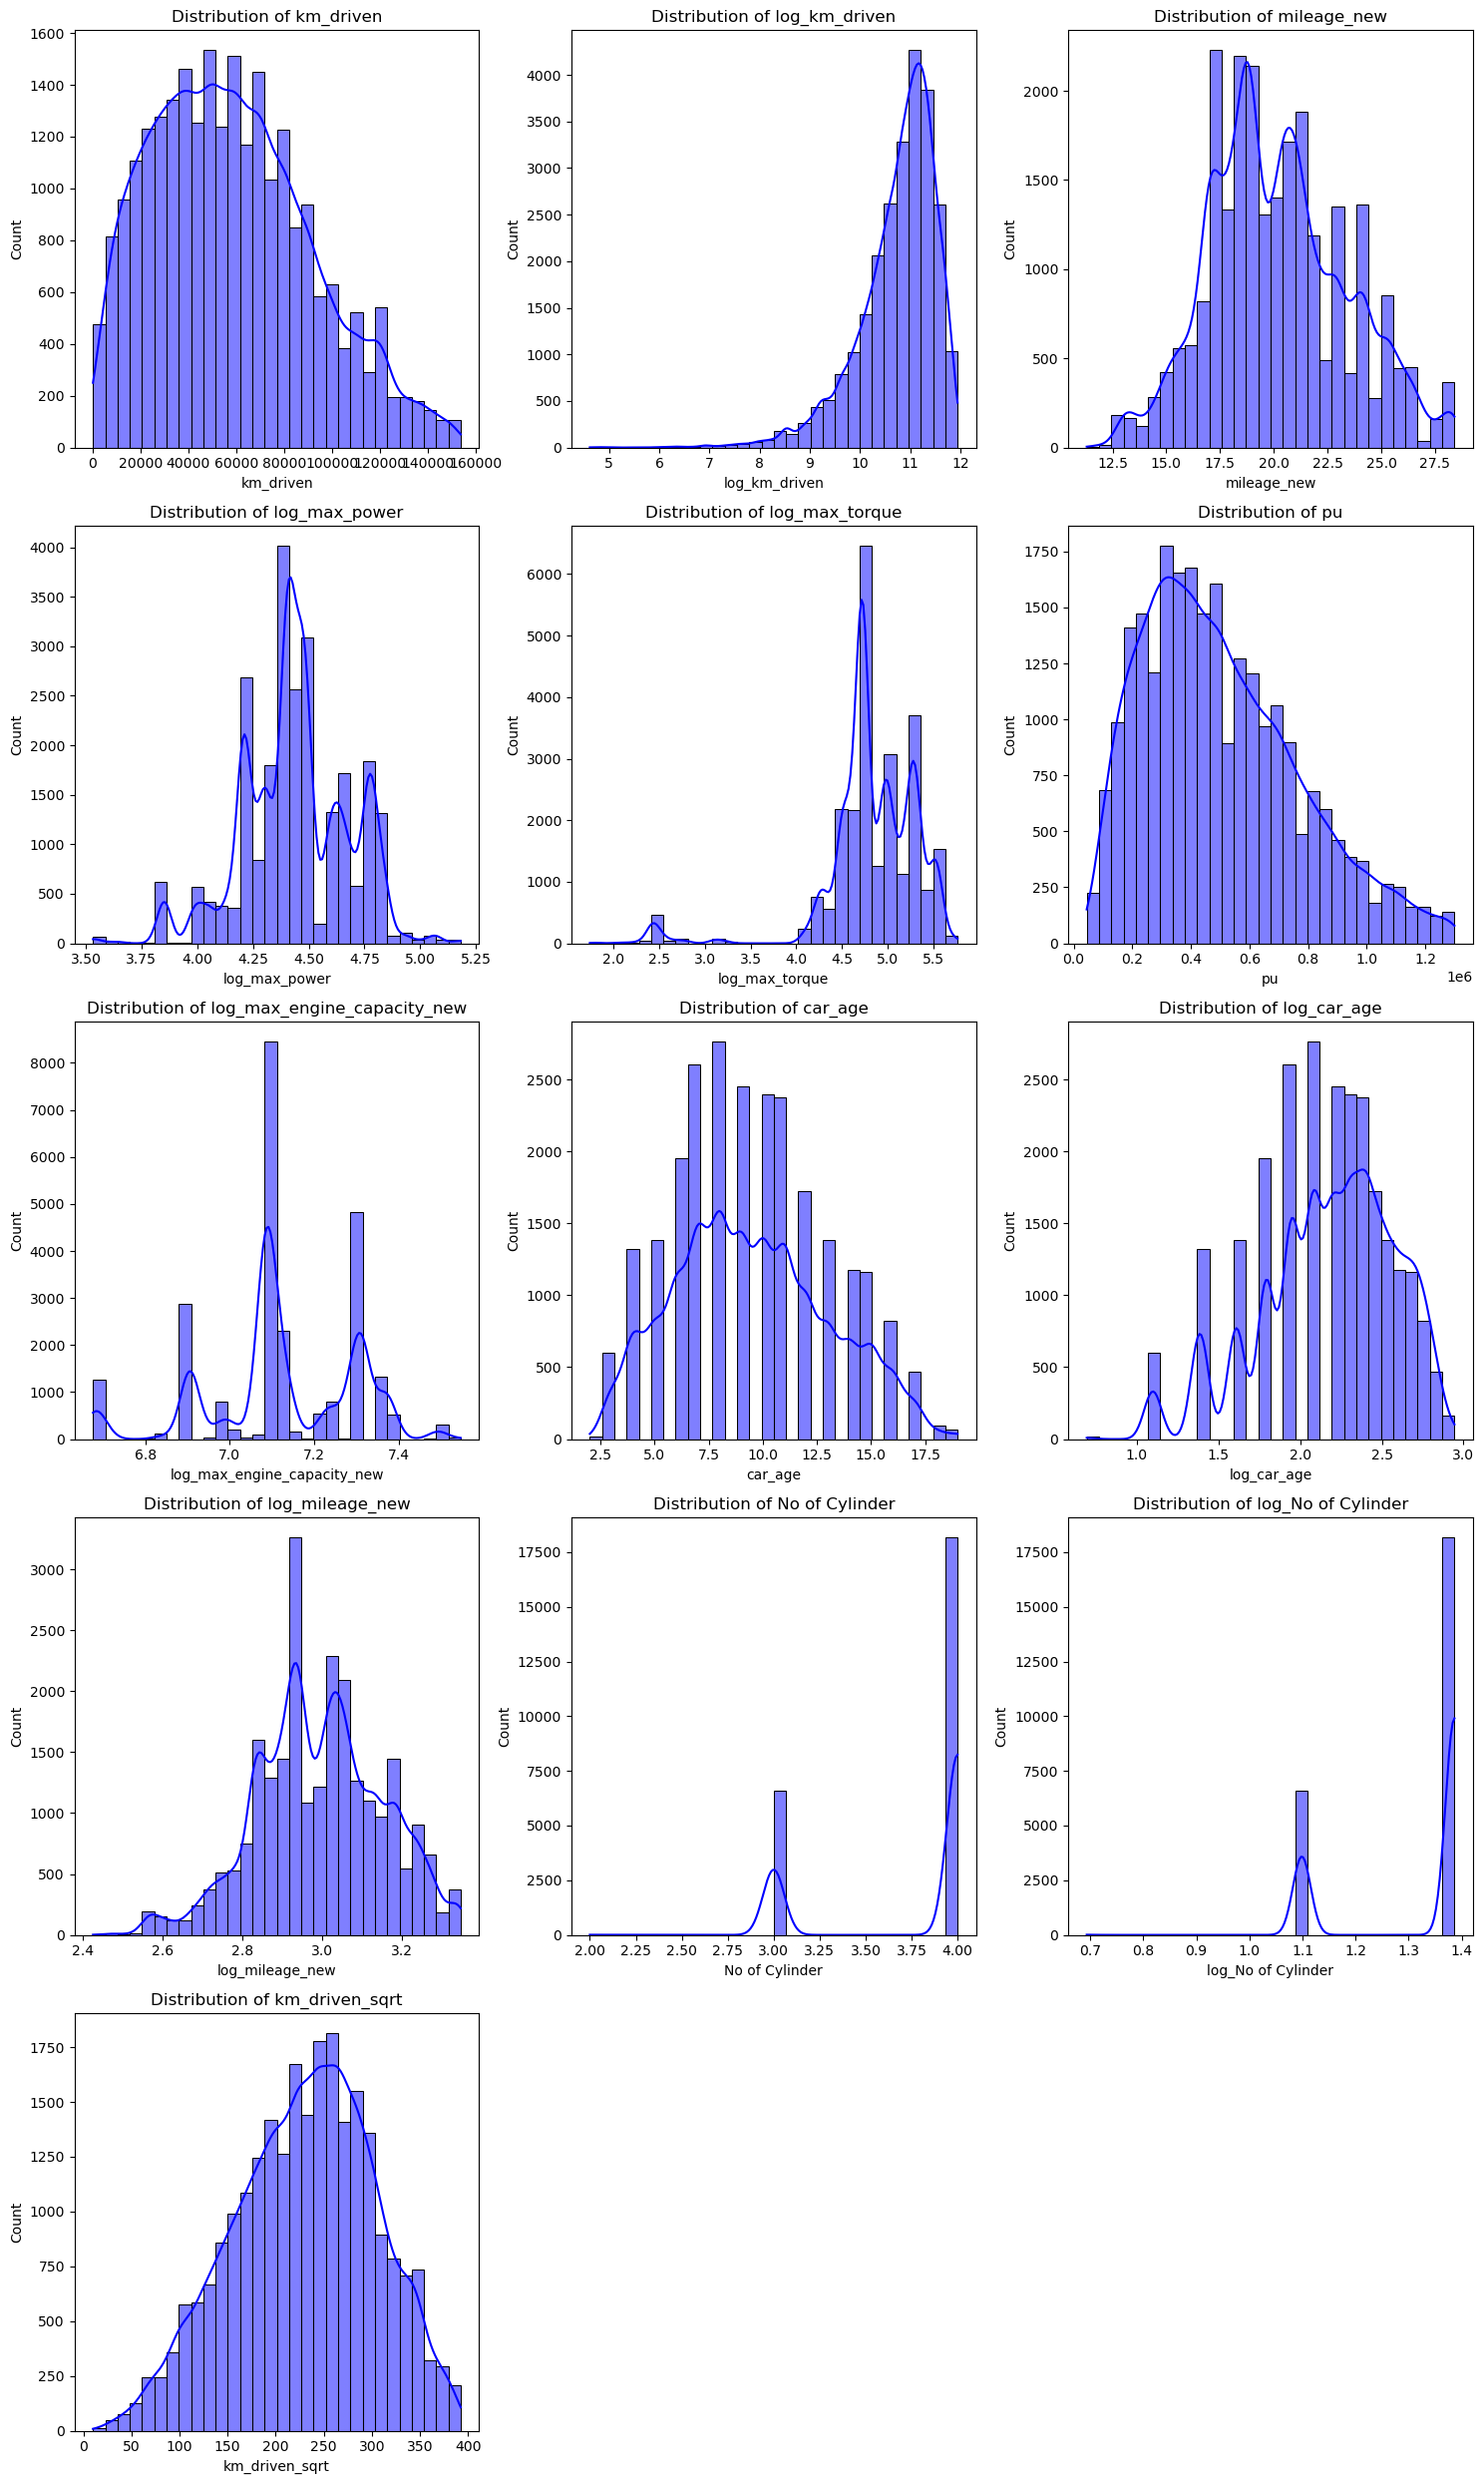

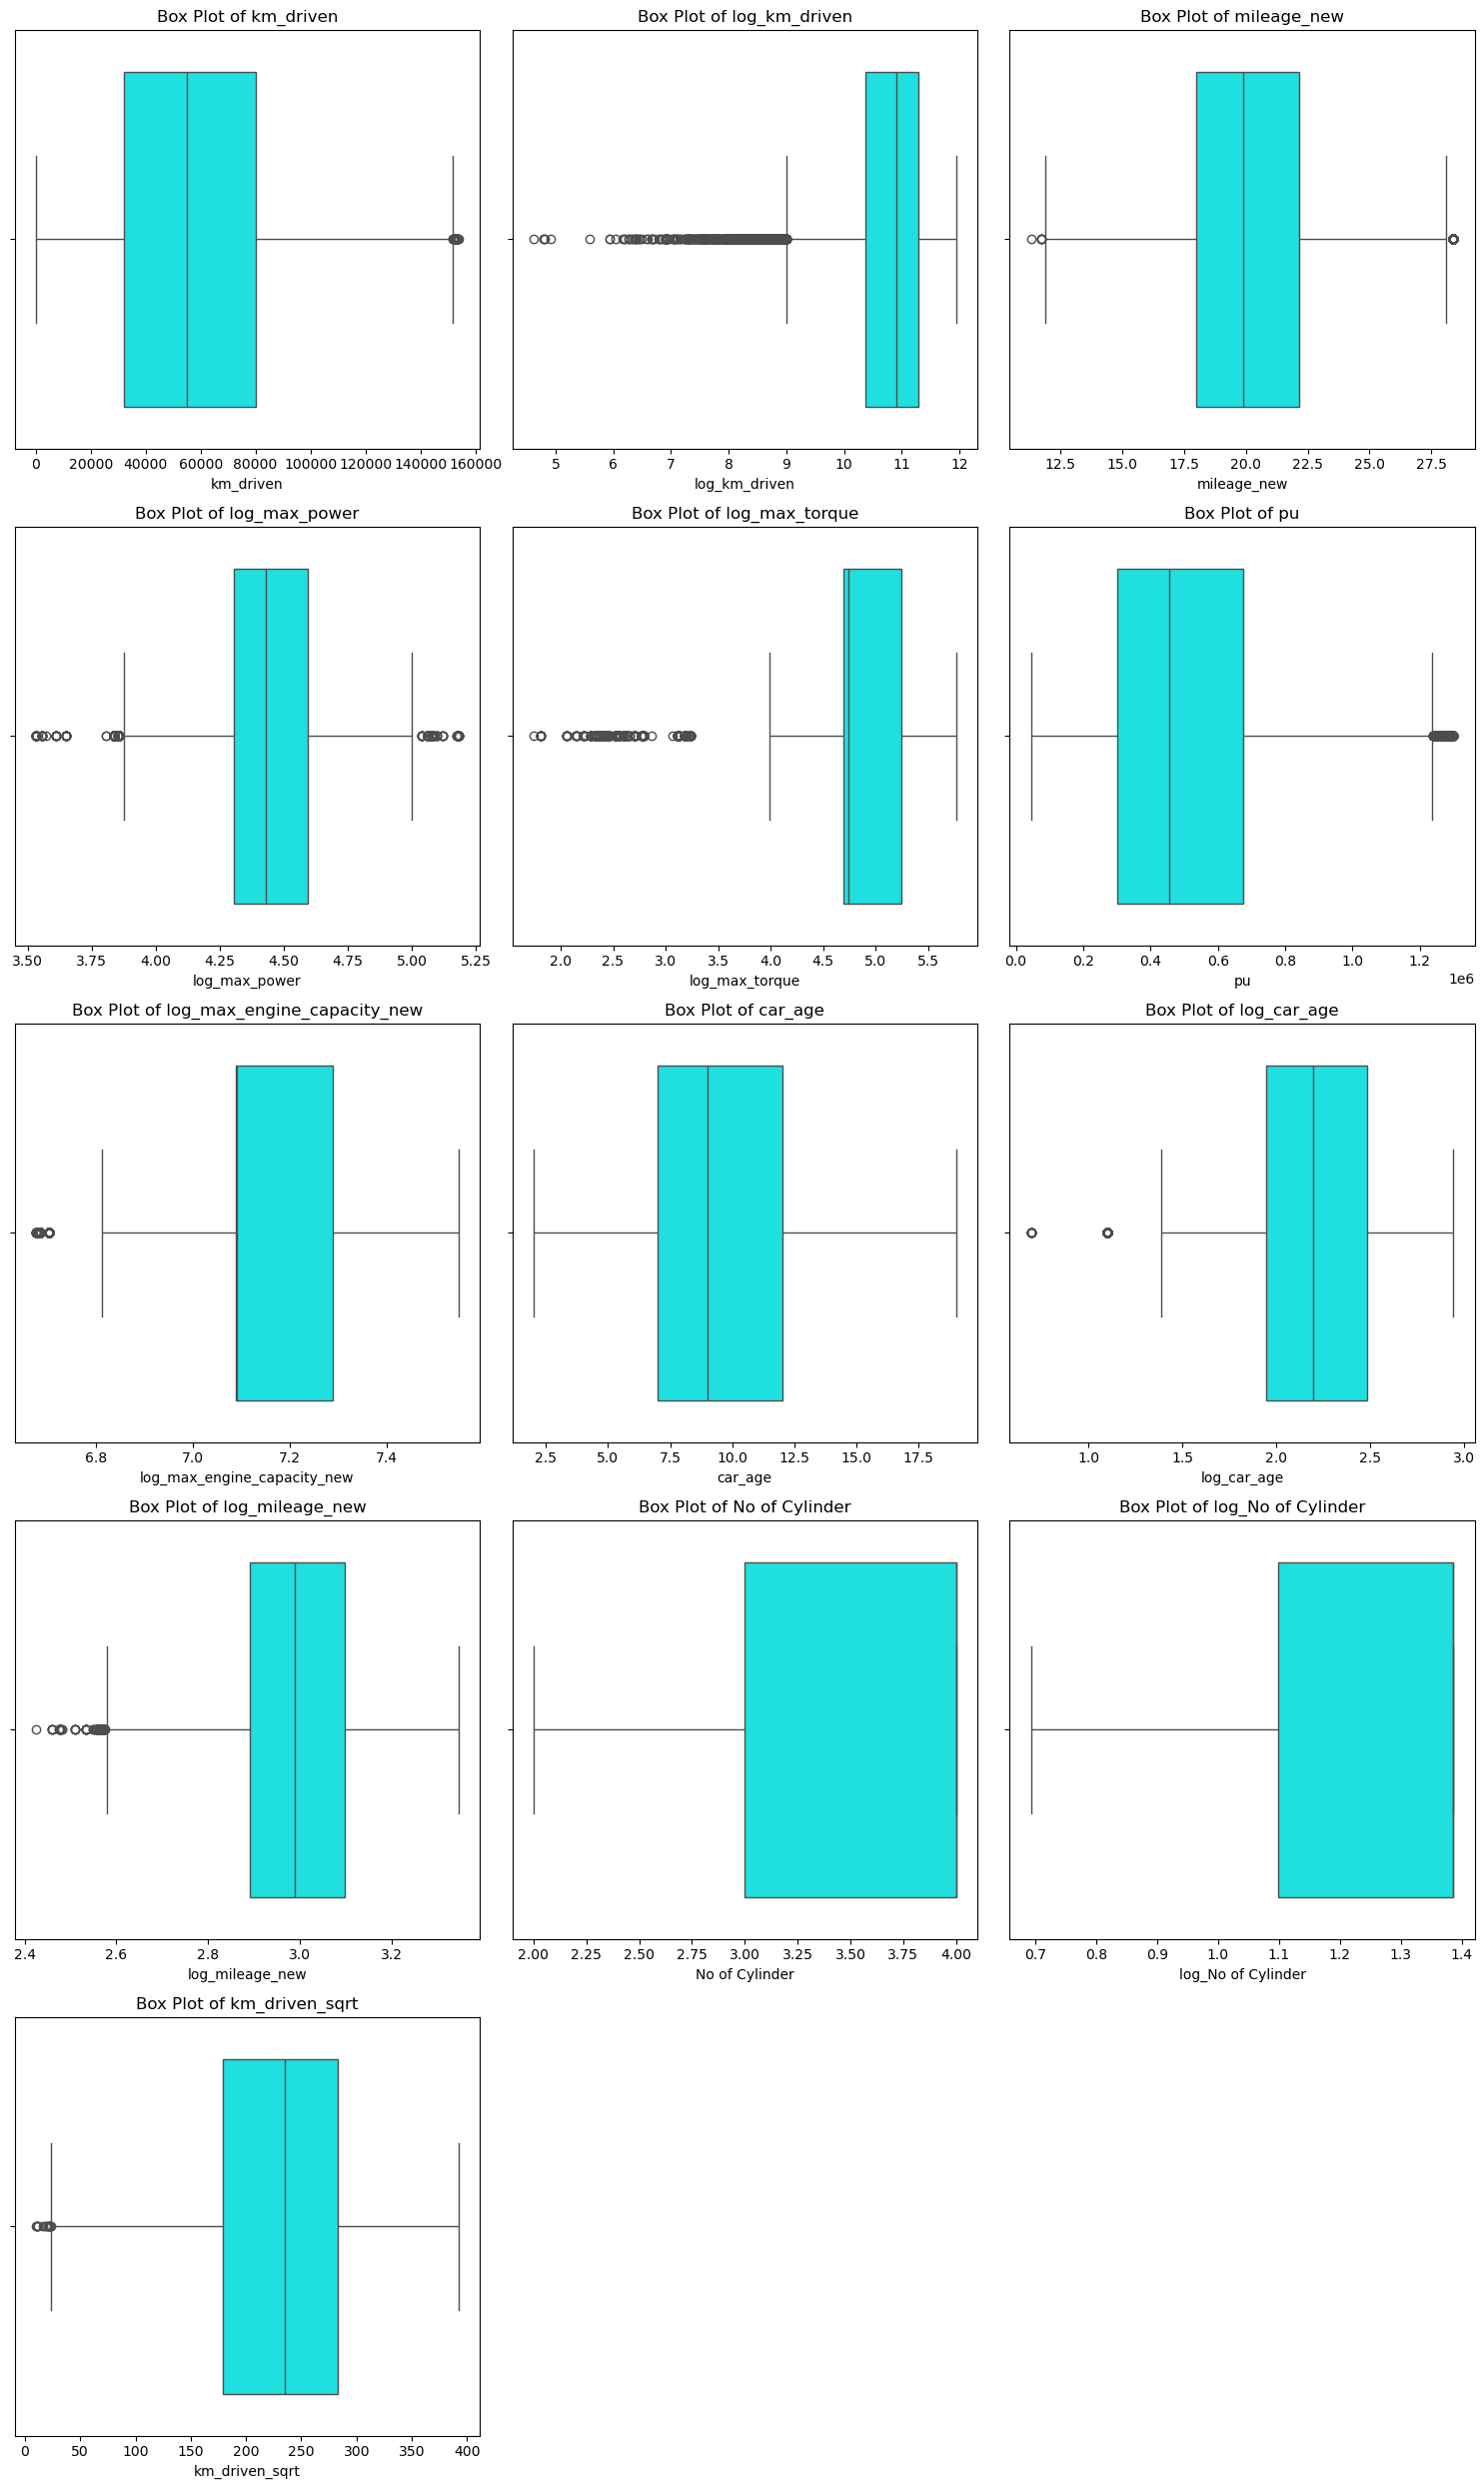

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import math
import numpy as np

# Define numerical columns with validation
numerical_columns = [
    "km_driven", "log_km_driven", "mileage_new",
    "log_max_power", "log_max_torque", "pu",
    "log_max_engine_capacity_new", "car_age", "log_car_age", "log_mileage_new",
    "No of Cylinder", "log_No of Cylinder", "km_driven_sqrt", "km_driven_boxcox"
]

# Calculate grid dimensions with validation
n_cols = 3
n_rows = math.ceil(len(numerical_columns) / n_cols)
print(f"Grid dimensions: {n_rows} rows, {n_cols} columns")

# Create figure with optimized size
plt.figure(figsize=(15, 5 * n_rows))

# Plot histograms with validation
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.histplot(df[feature], kde=True, bins=30, color='blue')
    plt.title(f'Distribution of {feature}')
    
    # Display validation statistics
    print(f"\nValidation for {feature}:")
    print(f"Mean: {df[feature].mean():.2f}")
    print(f"Std: {df[feature].std():.2f}")
    print(f"Skewness: {df[feature].skew():.2f}")

plt.tight_layout()
plt.show()

# Create box plots with validation
plt.figure(figsize=(15, 5 * n_rows))
for i, feature in enumerate(numerical_columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[feature], color='cyan')
    plt.title(f'Box Plot of {feature}')
    
    # Display outlier statistics
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[feature][(df[feature] < (Q1 - 1.5 * IQR)) | (df[feature] > (Q3 + 1.5 * IQR))]
    print(f"\nOutliers in {feature}: {len(outliers)} ({(len(outliers)/len(df)*100):.2f}%)")

plt.tight_layout()
plt.show()

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_51"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_230 (Dense)               │ (None, 512)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_88 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_231 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_89 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_232 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_90 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_233 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_91 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_234 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,289 (923.00 KB)

 Trainable params: 236,289 (923.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 8.6665 - mae: 2.0371 - val_loss: 1.4126 - val_mae: 1.1162
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.3221 - mae: 1.2315 - val_loss: 0.7849 - val_mae: 0.8285
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.4085 - mae: 0.9616 - val_loss: 0.0919 - val_mae: 0.2265
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.8098 - mae: 0.7199 - val_loss: 0.4125 - val_mae: 0.5878
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5377 - mae: 0.5868 - val_loss: 0.1871 - val_mae: 0.3675
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4589 - mae: 0.5393 - val_loss: 0.1379 - val_mae: 0.3117
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4111 - mae: 0.5106 - val_loss: 0.0780 - val_mae: 0.2107
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.3985 - mae: 0.5047 - val_loss: 0.0707 - val_mae: 0.2086
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/

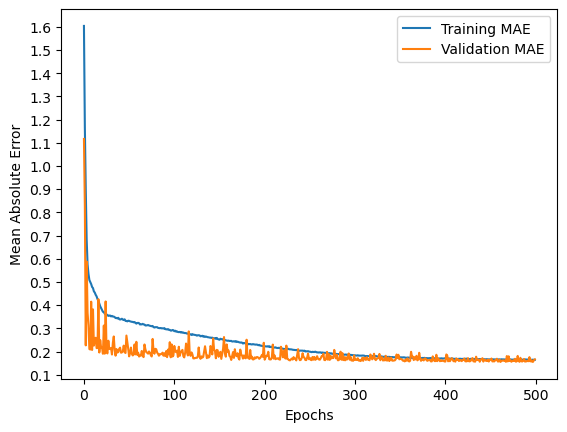

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define model architecture with validation
model = Sequential([
    Dense(512, activation="leaky_relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(256, activation="leaky_relu"),
    Dropout(0.2),
    Dense(256, activation="leaky_relu"),
    Dropout(0.2),
    Dense(128, activation="leaky_relu"),
    Dropout(0.1),
    Dense(1)
])

# Define callbacks for optimization
early_stopping = EarlyStopping(
    patience=50,
    min_delta=0.001,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=20,
    min_lr=1e-6,
    verbose=1
)

# Compile model with validation
model.compile(
    optimizer="rmsprop",
    loss="mse",
    metrics=["mae"]
)

# Train with validation
history = model.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Plot results with validation
plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Training MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True, alpha=0.3)
plt.locator_params(axis='y', nbins=30)
plt.show()

# Display final metrics
print("\nFinal Metrics:")
print(f"Training MAE: {history.history['mae'][-1]:.4f}")
print(f"Validation MAE: {history.history['val_mae'][-1]:.4f}")
print(f"Best Validation MAE: {min(history.history['val_mae']):.4f}")
print(f"Best Epoch: {np.argmin(history.history['val_mae']) + 1}")

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

def evaluate_predictions(y_true_log, y_pred_log):
    """Evaluate predictions with validation and comprehensive metrics."""
    # Convert to original scale with validation
    y_true = np.exp(y_true_log)
    y_pred = np.exp(y_pred_log)
    
    # Calculate metrics
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    
    # Display validation statistics
    print("\nPrediction Validation:")
    print(f"MAE in original units: {mae:.2f}")
    print(f"MAPE: {mape:.2f}%")
    print(f"RMSE: {rmse:.2f}")
    
    # Display distribution of errors
    errors = y_true - y_pred
    print("\nError Distribution:")
    print(f"Mean error: {np.mean(errors):.2f}")
    print(f"Std error: {np.std(errors):.2f}")
    print(f"Min error: {np.min(errors):.2f}")
    print(f"Max error: {np.max(errors):.2f}")
    
    return mae, mape, rmse

# Make predictions and evaluate
y_pred_log = model11.predict(X_train).flatten()
y_true_log = y_train

# Evaluate predictions
mae, mape, rmse = evaluate_predictions(y_true_log, y_pred_log)

619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAE in original price units: 71763.14765281862


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_52"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_235 (Dense)               │ (None, 128)            │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_92 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_236 (Dense)               │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_93 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_237 (Dense)               │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_94 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_238 (Dense)               │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_95 (Dropout)            │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_239 (Dense)               │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,417 (48.50 KB)

 Trainable params: 12,417 (48.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 42.9359 - mae: 4.9001 - val_loss: 0.9670 - val_mae: 0.9071
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 5.5317 - mae: 1.8695 - val_loss: 0.3004 - val_mae: 0.4759
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 4.5104 - mae: 1.6875 - val_loss: 0.3722 - val_mae: 0.5480
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 3.6970 - mae: 1.5269 - val_loss: 0.2967 - val_mae: 0.4888
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.9947 - mae: 1.3625 - val_loss: 0.2993 - val_mae: 0.4945
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.5272 - mae: 1.2485 - val_loss: 0.0932 - val_mae: 0.2493
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 2.1860 - mae: 1.1607 - val_loss: 0.0796 - val_mae: 0.2215
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.9532 - mae: 1.1019 - val_loss: 0.0946 - val_mae: 0.2514
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms

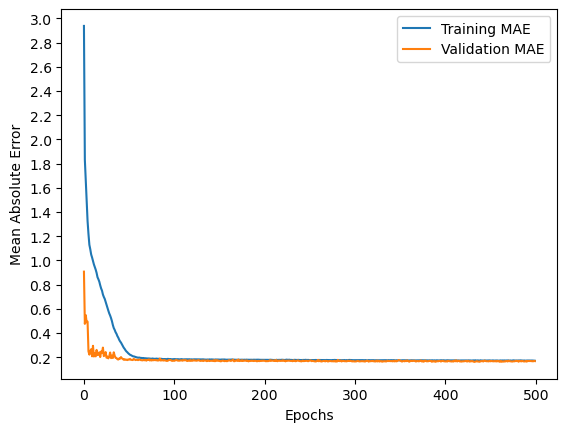

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau

model = Sequential([
    Dense(128, activation='relu', kernel_initializer='he_normal', input_shape=(X_train.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),
    Dense(32, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),
    Dense(16, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.1),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_mae',
    factor=0.5,
    patience=20,
    min_lr=1e-6
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_data=(X_val, y_val),
    callbacks=[lr_scheduler],
    batch_size=128,
    verbose=1
)

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Get predictions in log scale and flatten in case of extra dimensions
log_preds = model1.predict(X_train).ravel()  # ravel() is clearer than flatten()
log_true = y_train

# Convert from log scale back to original scale
preds = np.exp(log_preds)
true = np.exp(log_true)

# Compute MAE in original scale
mae = mean_absolute_error(true, preds)
print(f"MAE in original price units: {mae:.2f}")


619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 850us/step
MAE in original price units: 70721.10167648488


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def create_neural_network(input_features):
    model = Sequential([
        Dense(512, activation="relu", input_shape=(input_features,)),
        Dropout(0.1),
        Dense(256, activation="relu"),
        Dropout(0.2),
        Dense(256, activation="relu"),
        Dropout(0.2),
        Dense(128, activation="relu"),
        Dropout(0.1),
        Dense(1)
    ])
    
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

early_stopping = EarlyStopping(
    patience=50,
    min_delta=0.001,
    restore_best_weights=True
)

model = create_neural_network(X_train.shape[1])
history = model.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_val, y_val),
    callbacks=[early_stopping],
    verbose=1
)

def plot_training(history):
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['mae'], label='Training MAE')
    plt.plot(history.history['val_mae'], label='Validation MAE')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Absolute Error')
    plt.legend()
    plt.grid(True)
    plt.locator_params(axis='y', nbins=30)
    plt.show()

plot_training(history)

c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_53"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_240 (Dense)               │ (None, 512)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_96 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_241 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_97 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_242 (Dense)               │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_98 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_243 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_99 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_244 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 236,289 (923.00 KB)

 Trainable params: 236,289 (923.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 8.5610 - mae: 2.0256 - val_loss: 6.8229 - val_mae: 2.5860
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.6097 - mae: 1.3192 - val_loss: 0.1969 - val_mae: 0.3646
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.6098 - mae: 1.0194 - val_loss: 0.0924 - val_mae: 0.2331
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - loss: 0.6532 - mae: 0.6466 - val_loss: 0.1088 - val_mae: 0.2513
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.5326 - mae: 0.5818 - val_loss: 0.1027 - val_mae: 0.2409
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5065 - mae: 0.5686 - val_loss: 0.0693 - val_mae: 0.2011
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4746 - mae: 0.5517 - val_loss: 0.1593 - val_mae: 0.3190
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.4557 - mae: 0.5392 - val_loss: 0.0676 - val_mae: 0.1981
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/

In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict on training set (in log scale)
log_preds = model4.predict(X_train).ravel()
log_true = y_train

# Convert predictions and true values to original scale
preds = np.exp(log_preds)
true = np.exp(log_true)

# Calculate Mean Absolute Error in original price units
mae = mean_absolute_error(true, preds)
print(f"MAE in original price units: {mae:.2f}")


619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAE in original price units: 80136.50945127915


Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_95 (Dense)                │ (None, 512)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_76 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_77 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_78 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_98 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_79 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_99 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 178,689 (698.00 KB)

 Trainable params: 178,689 (698.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - loss: 9.9141 - mae: 2.1543 - val_loss: 0.2681 - val_mae: 0.3987
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 3.0208 - mae: 1.3912 - val_loss: 1.0295 - val_mae: 0.9345
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 2.4317 - mae: 1.2537 - val_loss: 0.5615 - val_mae: 0.6858
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.6967 - mae: 1.0408 - val_loss: 0.3273 - val_mae: 0.4845
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.2009 - mae: 0.8754 - val_loss: 0.7196 - val_mae: 0.8082
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.9271 - mae: 0.7688 - val_loss: 0.1070 - val_mae: 0.2695
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - loss: 0.7987 - mae: 0.7104 - val_loss: 0.2086 - val_mae: 0.4028
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 0.7655 - mae: 0.6964 - val_loss: 0.0914 - val_mae: 0.2426
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/

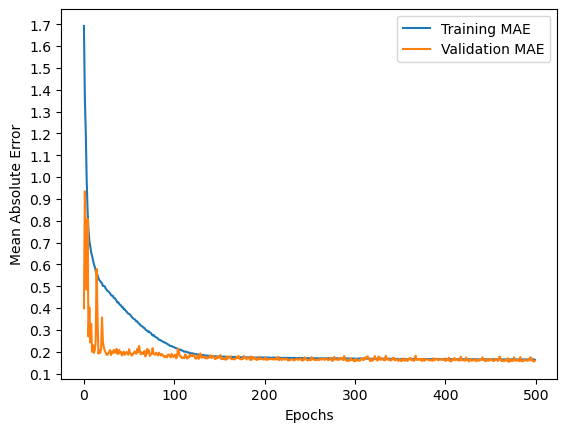

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, LeakyReLU
import matplotlib.pyplot as plt

# Build the model
model5 = Sequential([
    Dense(512, input_shape=(X_train.shape[1],)),
    LeakyReLU(alpha=0.1),
    Dropout(0.1),

    Dense(256),
    LeakyReLU(alpha=0.1),
    Dropout(0.2),

    Dense(128, activation="relu"),
    Dropout(0.2),

    Dense(64, activation="relu"),
    Dropout(0.1),

    Dense(1, activation="linear")
])

# Compile the model
model5.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
model5.summary()

# Train the model
history = model5.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_val, y_val),
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Training MAE', color='blue')
plt.plot(history.history['val_mae'], label='Validation MAE', color='orange')
plt.title("Training vs Validation MAE")
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.legend()
plt.grid(True)
plt.locator_params(axis='y', nbins=30)  # More y-axis ticks
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict using the trained model
y_pred_log = model5.predict(X_train).flatten()  # Predictions in log scale
y_true_log = y_train  # Ground truth in log scale

# Convert predictions and true values back to original scale
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Compute Mean Absolute Error in original scale (e.g., price)
mae_real = mean_absolute_error(y_true, y_pred)

print(f"MAE in original price units: {mae_real:,.2f}")


619/619 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
MAE in original price units: 65290.17135792672


c:\Users\narut\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_100 (Dense)               │ (None, 512)            │         6,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_80 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_81 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_102 (Dense)               │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_82 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_103 (Dense)               │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_83 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_104 (Dense)               │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 433,153 (1.65 MB)

 Trainable params: 433,153 (1.65 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 8.2710 - mae: 2.0262 - val_loss: 1.7184 - val_mae: 1.2404
Epoch 2/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 2.8061 - mae: 1.3546 - val_loss: 0.9707 - val_mae: 0.9154
Epoch 3/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 2.0685 - mae: 1.1639 - val_loss: 0.3813 - val_mae: 0.5540
Epoch 4/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.1517 - mae: 0.8581 - val_loss: 0.1502 - val_mae: 0.3040
Epoch 5/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.7924 - mae: 0.7153 - val_loss: 0.1735 - val_mae: 0.3373
Epoch 6/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.6342 - mae: 0.6371 - val_loss: 0.0674 - val_mae: 0.2004
Epoch 7/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.5207 - mae: 0.5768 - val_loss: 0.1520 - val_mae: 0.3315
Epoch 8/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4984 - mae: 0.5652 - val_loss: 0.1695 - val_mae: 0.3422
Epoch 9/500
619/619 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/

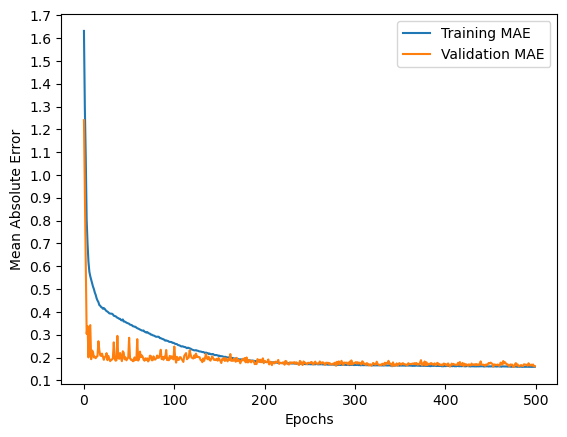

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

# Build the model
model9 = Sequential([
    Dense(512, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.1),
    Dense(512, activation="relu"),
    Dropout(0.2),
    Dense(256, activation="relu"),
    Dropout(0.2),
    Dense(128, activation="relu"),
    Dropout(0.1),
    Dense(1, activation="linear")  # Explicit linear activation for regression
])

# Compile the model
model9.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])

# Print model architecture
model9.summary()

# Train the model
history = model9.fit(
    X_train, y_train,
    epochs=500,
    validation_data=(X_val, y_val),
    verbose=1
)

# Plot training history
plt.figure(figsize=(10, 6))
plt.plot(history.history['mae'], label='Training MAE', linewidth=2)
plt.plot(history.history['val_mae'], label='Validation MAE', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Mean Absolute Error')
plt.title('Model Training vs Validation MAE')
plt.legend()
plt.grid(True)
plt.locator_params(axis='y', nbins=30)
plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import mean_absolute_error
import numpy as np

# Predict (in log scale)
y_pred_log = model9.predict(X_train).flatten()
y_true_log = y_train.flatten()  # ensure shape matches prediction

# Convert predictions and true values back to original scale (exponentiation)
y_pred = np.exp(y_pred_log)
y_true = np.exp(y_true_log)

# Calculate Mean Absolute Error in actual price units
mae_real = mean_absolute_error(y_true, y_pred)

print("MAE in original price units:", round(mae_real, 2))


619/619 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
MAE in original price units: 66885.55996393503
